# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Mohamad Rangga Nur Faizin
- Email: mohammad.rangga.n.f@gmail.com
- Id Dicoding: rangfaziii19

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv('students_performance.csv', sep=';')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset shape: (4424, 37)
Columns: ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Status']


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


## Data Understanding

In [3]:
print(df.describe().T.to_string())
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
print(f"\nTarget distribution:\n{df['Status'].value_counts()}")

                                               count         mean          std    min      25%          50%          75%          max
Marital_status                                4424.0     1.178571     0.605747   1.00     1.00     1.000000     1.000000     6.000000
Application_mode                              4424.0    18.669078    17.484682   1.00     1.00    17.000000    39.000000    57.000000
Application_order                             4424.0     1.727848     1.313793   0.00     1.00     1.000000     2.000000     9.000000
Course                                        4424.0  8856.642631  2063.566416  33.00  9085.00  9238.000000  9556.000000  9991.000000
Daytime_evening_attendance                    4424.0     0.890823     0.311897   0.00     1.00     1.000000     1.000000     1.000000
Previous_qualification                        4424.0     4.577758    10.216592   1.00     1.00     1.000000     1.000000    43.000000
Previous_qualification_grade                  4424.0   132.613

## Data Preparation / Preprocessing

In [4]:
# Hanya gunakan data dengan label akhir (Dropout & Graduate)
model_df = df[df['Status'].isin(['Dropout','Graduate'])].copy()
model_df['Target'] = (model_df['Status']=='Dropout').astype(int)
model_df = model_df.drop(columns=['Status'])
X = model_df.drop(columns=['Target'])
y = model_df['Target']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Model Training dengan Pipeline

In [5]:
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                           ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                           ('encoder', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
    ]
)

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_split=5, random_state=42, class_weight='balanced'))
])
model_pipeline.fit(X_train, y_train)
print('Model berhasil dilatih!')

Model berhasil dilatih!


## Evaluation

=== Classification Report ===
              precision    recall  f1-score   support

    Graduate       0.93      0.94      0.93       442
     Dropout       0.91      0.88      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726

ROC-AUC Score: 0.9709


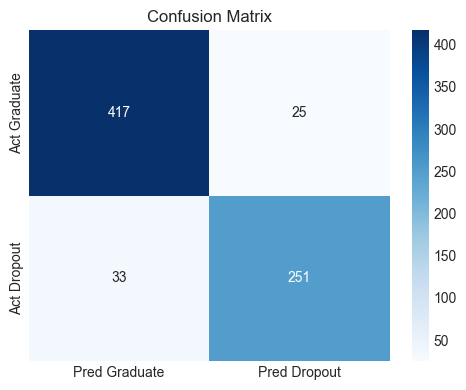

In [6]:
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:,1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Graduate','Dropout']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Graduate','Pred Dropout'], yticklabels=['Act Graduate','Act Dropout'], ax=ax)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150)
plt.show()

### ROC Curve

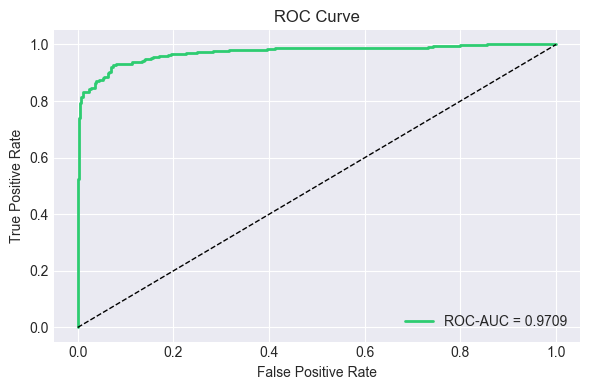

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}', color='#2ecc71', lw=2)
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('plot_roc.png', dpi=150)
plt.show()

### Feature Importance

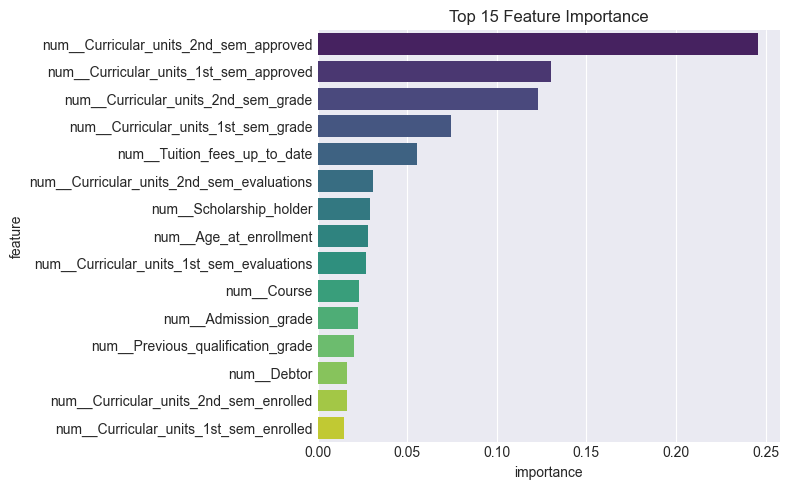

In [8]:
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = model_pipeline.named_steps['classifier'].feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=fi_df, y='feature', x='importance', palette='viridis', ax=ax)
ax.set_title('Top 15 Feature Importance')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()

### Menyimpan Model

In [9]:
import joblib
import os

os.makedirs('model', exist_ok=True)
joblib.dump(model_pipeline, 'model/model.pkl')
print('Model saved to model/model.pkl')

# Quick test
loaded = joblib.load('model/model.pkl')
print(f'Loaded model test prediction: {loaded.predict(X_test[:3])}')

Model saved to model/model.pkl


Loaded model test prediction: [0 0 1]
